# LeetCode #103: Binary Tree Zigzag Level Order Traversal

https://leetcode.com/problems/binary-tree-zigzag-level-order-traversal/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| BFS + Reverse Alternate Levels | O(n) | O(n) | Normal BFS, reverse odd-indexed levels |
| **BFS + Direction Flag ★** | **O(n)** | **O(n)** | Toggle leftToRight; insert at front or back of deque |

---

## Understanding the Methods

### Brute Force (BFS + Reverse)
Run standard BFS collecting each level normally. After collecting all levels, reverse the odd-indexed ones. Simple but requires post-processing.

### BFS + Direction Flag (Optimal ★)
Use a queue for BFS. Maintain a `leftToRight` boolean. For each level, use a LinkedList (deque): if leftToRight, AddLast; else AddFirst. Toggle flag after each level. O(n) with no extra reversal passes.

## Constraints
- Number of nodes: [0, 2000]
- Node values: [-100, 100]

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> ZigzagLevelOrder(TreeNode root) {
        var result = new List<IList<int>>();
        if (root == null) return result;
        var queue = new Queue<TreeNode>();
        queue.Enqueue(root);
        bool leftToRight = true;
        while (queue.Count > 0) {
            int size = queue.Count;
            var level = new LinkedList<int>();
            for (int i = 0; i < size; i++) {
                var node = queue.Dequeue();
                if (leftToRight) level.AddLast(node.val);
                else             level.AddFirst(node.val);
                if (node.left  != null) queue.Enqueue(node.left);
                if (node.right != null) queue.Enqueue(node.right);
            }
            result.Add(new List<int>(level));
            leftToRight = !leftToRight;
        }
        return result;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def zigzagLevelOrder(self, root) -> list[list[int]]:
        if not root:
            return []
        result, queue, left_to_right = [], deque([root]), True
        while queue:
            level = deque()
            for _ in range(len(queue)):
                node = queue.popleft()
                if left_to_right: level.append(node.val)
                else:             level.appendleft(node.val)
                if node.left:  queue.append(node.left)
                if node.right: queue.append(node.right)
            result.append(list(level))
            left_to_right = not left_to_right
        return result

### Go

In [ ]:
func zigzagLevelOrder(root *TreeNode) [][]int {
    if root == nil { return nil }
    result := [][]int{}
    queue  := []*TreeNode{root}
    leftToRight := true
    for len(queue) > 0 {
        size  := len(queue)
        level := make([]int, size)
        for i := 0; i < size; i++ {
            node  := queue[0]; queue = queue[1:]
            if leftToRight { level[i] = node.Val } else { level[size-1-i] = node.Val }
            if node.Left  != nil { queue = append(queue, node.Left) }
            if node.Right != nil { queue = append(queue, node.Right) }
        }
        result = append(result, level)
        leftToRight = !leftToRight
    }
    return result
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::VecDeque;

impl Solution {
    pub fn zigzag_level_order(root: Option<Rc<RefCell<TreeNode>>>) -> Vec<Vec<i32>> {
        let mut result = vec![];
        let Some(r) = root else { return result; };
        let mut queue = VecDeque::from([r]);
        let mut left_to_right = true;
        while !queue.is_empty() {
            let size = queue.len();
            let mut level = vec![0i32; size];
            for i in 0..size {
                let node = queue.pop_front().unwrap();
                let val  = node.borrow().val;
                if left_to_right { level[i] = val; } else { level[size-1-i] = val; }
                if let Some(l) = node.borrow().left.clone()  { queue.push_back(l); }
                if let Some(r) = node.borrow().right.clone() { queue.push_back(r); }
            }
            result.push(level);
            left_to_right = !left_to_right;
        }
        result
    }
}

## Example Scenarios

### 1. Common Case — Standard 3-Level Zigzag
**Input:** `root = [3, 9, 20, null, null, 15, 7]`

Level 0 (L→R): collect [3]. Level 1 (R←L): BFS dequeues 9 then 20, but AddFirst reverses insertion order → [20, 9]. Level 2 (L→R): dequeue 15 then 7, AddLast → [15, 7].

*Why tricky:* Baseline zigzag. The direction flag flips each level; AddFirst vs AddLast handles ordering without a separate reverse pass.

$T(n) = O(5)$, direction toggles: $L \to R \to L$

**Output:** `[[3], [20, 9], [15, 7]]`

### 2. Slightly Complex — 4-Level Perfect Tree with Negatives
**Input:** `root = [1, -2, 3, -4, 5, -6, 7, 8, -9, 10, -11, 12, -13, 14, -15]`

4 levels with direction toggling. L0(→): [1]. L1(←): reverse [-2,3] → [3,-2]. L2(→): [-4,5,-6,7]. L3(←): reverse the 8-node level. Negatives interleaved with positives test that zigzag reordering does not confuse signs with structure.

*Why tricky:* Deeper tree with negatives. Four direction flips test the toggle logic thoroughly. Negative values must not affect index computations in AddFirst/AddLast.

$T(n) = O(15)$, $4$ direction toggles, mixed $\pm$ values

**Output:** `[[1], [3, -2], [-4, 5, -6, 7], [-15, 14, -13, 12, -11, 10, -9, 8]]`

### 3. Edge Case: Time Factor — Left-Skewed Chain (2000 Nodes)
**Input:** `root = 2000-node left-only chain, values 1 to 2000` (max constraint)

Each level has exactly 1 node. The direction flag flips 2000 times, but single-element levels are unaffected by reversal. BFS runs 2000 iterations at max $n$.

*Why tricky:* Maximum $n = 2000$ with 2000 levels. Direction toggles 2000 times with zero visible effect (single-element reversal is identity). A subtle verification trap — output is identical to normal level order.

$T(n) = O(2000)$, all toggles produce identity permutations

**Output:** `[[1], [2], [3], ..., [2000]]`

### 4. Edge Case: Space Factor — Wide Perfect Tree (1023 Nodes)
**Input:** `root = perfect binary tree, depth 10, 1023 nodes`

Queue peaks at 512 nodes. The direction-flag deque for level 9 holds 512 values inserted via AddFirst — each insertion is $O(1)$ for a deque but $O(k)$ for an array.

*Why tricky:* Peak queue = $n/2 = 512$. Using AddFirst on an *array* instead of a deque/linked-list would cause $O(k^2)$ per level. Tests that your data structure truly supports $O(1)$ front insertion.

$\max(|Q|) = 512$, AddFirst cost: $O(1)$ deque vs $O(k)$ array

**Output:** `10 levels, last level reversed (512 nodes)`

### 5. Almost-Impossible but Plausible — Palindromic Values per Level
**Input:** `root = [0, -100, 100, 99, -99, -99, 99]`

Level 0: [0]. Level 1 (R←L): reverse [-100, 100] → [100, -100]. Level 2 (L→R): [99, -99, -99, 99] — palindromic! Zigzag reversal yields the same sequence. A bug that skips the direction check for "already correct" levels would pass silently.

*Why tricky:* Palindromic level values are near-miss decoys. Output is identical whether you apply zigzag or not for level 2. Tests that the direction toggle is *always* applied, not conditionally. Boundary values $\pm 100$.

$\text{Level 2 palindrome: } [99, -99, -99, 99] = \text{reverse}([99, -99, -99, 99])$

**Output:** `[[0], [100, -100], [99, -99, -99, 99]]`

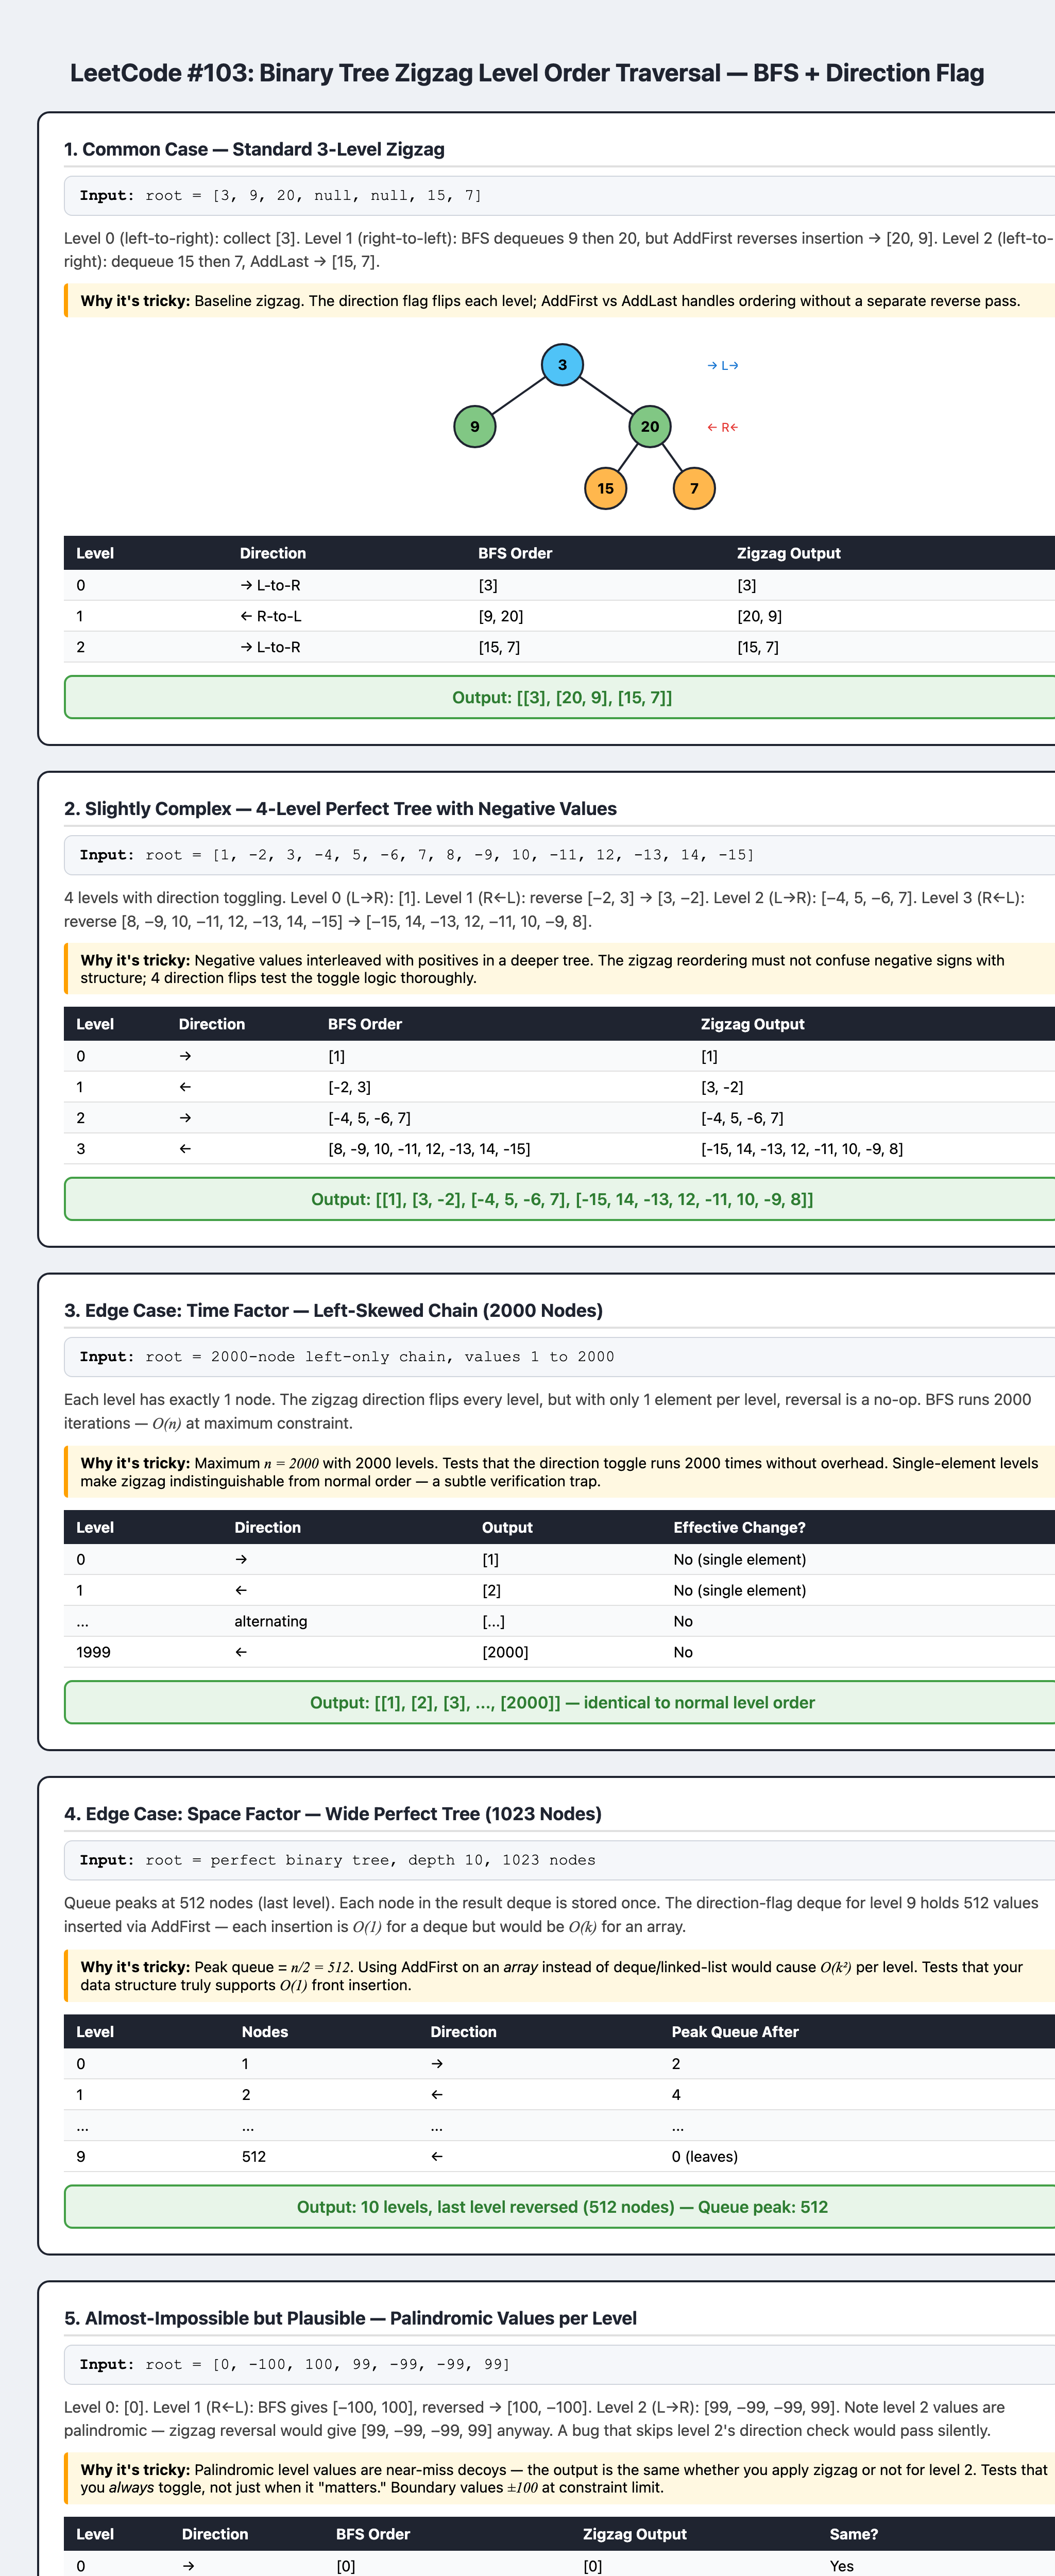